In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [3]:
# Membaca dataset
data = pd.read_csv("insurance.csv")

# Menampilkan 5 data pertama
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print("Shape dataset:", data.shape)
print("\nInformasi dataset:")
data.info()

print("\nMissing values:")
print(data.isnull().sum())

Shape dataset: (1338, 7)

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [5]:
# Independent variables / features
X = data.drop("charges", axis=1)

# Dependent variable / target
y = data["charges"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest

Target:
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


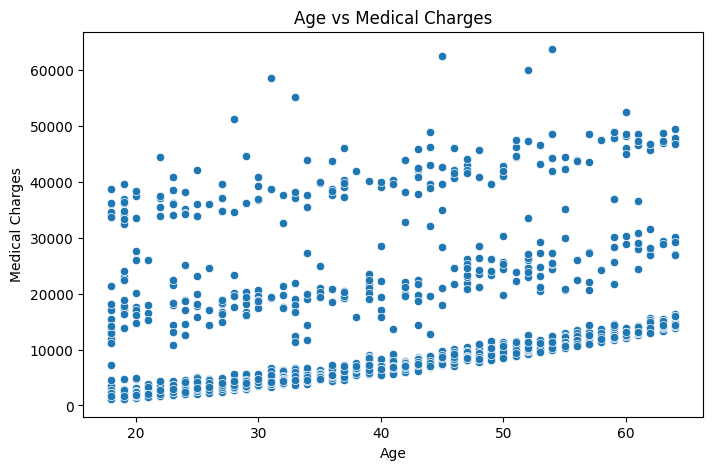

In [6]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="age",
    y="charges"
)

plt.title("Age vs Medical Charges")
plt.xlabel("Age")
plt.ylabel("Medical Charges")
plt.show()

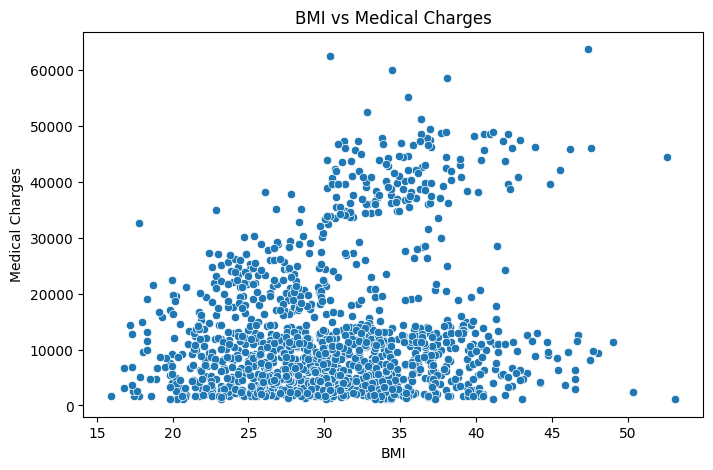

In [7]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=data,
    x="bmi",
    y="charges"
)

plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Medical Charges")
plt.show()

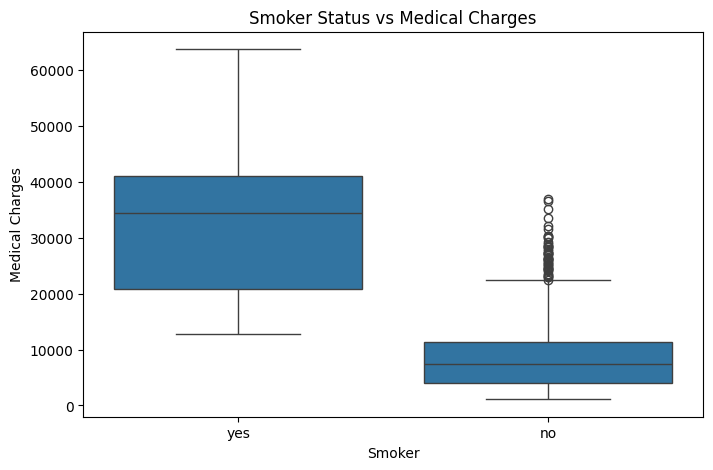

In [8]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x="smoker",
    y="charges"
)

plt.title("Smoker Status vs Medical Charges")
plt.xlabel("Smoker")
plt.ylabel("Medical Charges")
plt.show()

In [9]:
numeric_features = [
    "age",
    "bmi",
    "children"
]

categorical_features = [
    "sex",
    "smoker",
    "region"
]

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing :", X_test.shape[0])

Jumlah data training: 1070
Jumlah data testing : 268


In [12]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

In [13]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', LinearRegression())])

In [14]:
y_pred_linear = linear_model.predict(X_test)

In [15]:
r2_linear = r2_score(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)

print("Multiple Linear Regression")
print("--------------------------")
print("R-squared :", r2_linear)
print("MSE       :", mse_linear)
print("MAE       :", mae_linear)

Multiple Linear Regression
--------------------------
R-squared : 0.7835929767120723
MSE       : 33596915.85136146
MAE       : 4181.194473753649


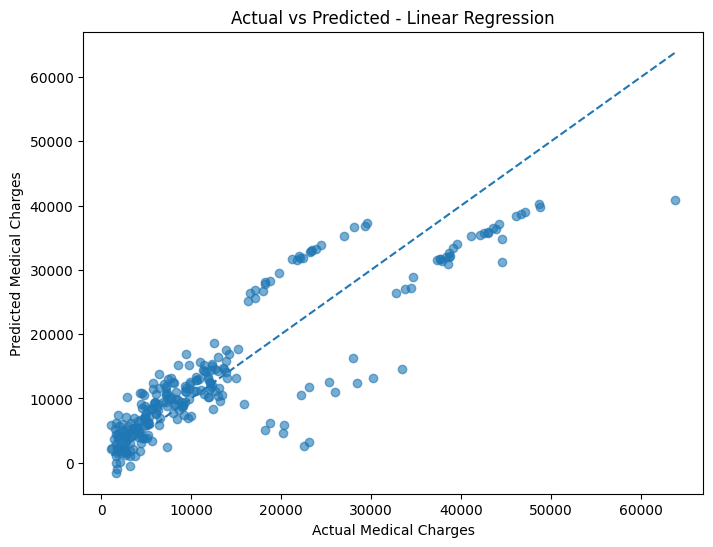

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.6
)

plt.xlabel("Actual Medical Charges")
plt.ylabel("Predicted Medical Charges")
plt.title("Actual vs Predicted - Linear Regression")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [17]:
svr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", SVR())
    ]
)

In [18]:
svr_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', SVR())])

In [19]:
y_pred_svr = svr_model.predict(X_test)

In [20]:
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print("SVR")
print("--------------------------")
print("R-squared :", r2_svr)
print("MSE       :", mse_svr)
print("MAE       :", mae_svr)

SVR
--------------------------
R-squared : -0.07149402790922443
MSE       : 166348088.63391805
MAE       : 8606.59226132562


In [21]:
param_grid = {
    "model__C": [10, 100, 500, 1000],
    "model__gamma": ["scale", 0.01, 0.1],
    "model__epsilon": [0.1, 0.5, 1]
}

In [22]:
grid_search = GridSearchCV(
    estimator=svr_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['age',
                                                                          'bmi',
                                                                          'children']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['sex',
                                                                          'smoker',
                                                                          'region'])])),
                                       ('model', SVR())]),
             n_jobs=-1,
             param_grid={'model__C': [10, 100, 500, 1000],
                         'model__epsilon': [0.1, 0.5, 1],
                         'model__gamma': ['scale', 0.01, 0.1]},
             scoring='r2')

In [23]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__C': 1000, 'model__epsilon': 1, 'model__gamma': 'scale'}


In [24]:
y_pred_svr_tuned = grid_search.predict(X_test)

r2_svr_tuned = r2_score(
    y_test,
    y_pred_svr_tuned
)

mse_svr_tuned = mean_squared_error(
    y_test,
    y_pred_svr_tuned
)

mae_svr_tuned = mean_absolute_error(
    y_test,
    y_pred_svr_tuned
)

print("Tuned SVR")
print("--------------------------")
print("R-squared :", r2_svr_tuned)
print("MSE       :", mse_svr_tuned)
print("MAE       :", mae_svr_tuned)

Tuned SVR
--------------------------
R-squared : 0.5937803622047089
MSE       : 63065083.47476665
MAE       : 3432.8807457294365


In [25]:
results = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "SVR Default",
        "SVR Tuned"
    ],
    "R-squared": [
        r2_linear,
        r2_svr,
        r2_svr_tuned
    ],
    "MSE": [
        mse_linear,
        mse_svr,
        mse_svr_tuned
    ],
    "MAE": [
        mae_linear,
        mae_svr,
        mae_svr_tuned
    ]
})

results

,Model,R-squared,MSE,MAE
0,Multiple Linear Regression,0.783593,3.359692e+07,4181.194474
1,SVR Default,-0.071494,1.663481e+08,8606.592261
2,SVR Tuned,0.593780,6.306508e+07,3432.880746


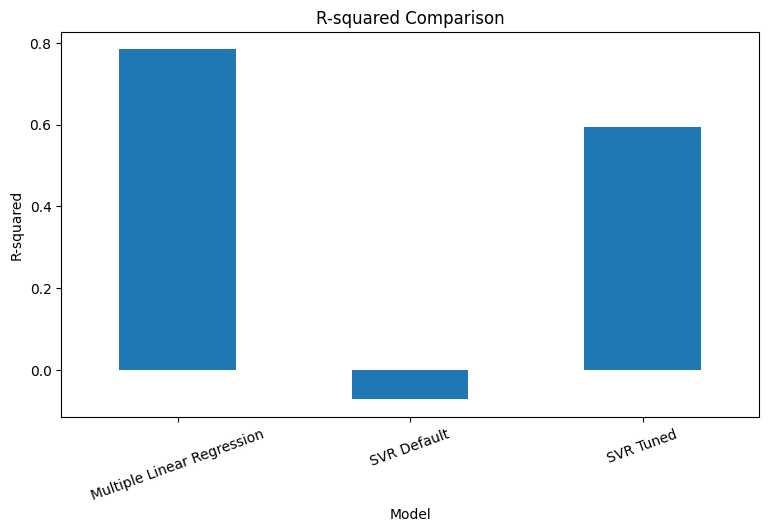

In [26]:
results_plot = results.set_index("Model")

results_plot["R-squared"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("R-squared Comparison")
plt.ylabel("R-squared")
plt.xticks(rotation=20)
plt.show()